This version is going to look at training on a given time series then looking at the likelihood of the testing series being possible given the train series. 

Train series: 2019-01-01 -> 2024-12-31

Test series: 2025-01-01 -> present

In [28]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import scipy.stats as stats

from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler  

from hmmlearn import hmm

seed = 123
random.seed(seed)

In [3]:
tickers = ["XLK","XLV","XLF","XLY","XLC","XLI","XLP","XLE","XLU","XLRE","XLB","^VIX", "^SPX"]
sector_data = yf.download(tickers, start="2019-01-01", auto_adjust = False)["Adj Close"]
returns = sector_data.pct_change().dropna()

[*********************100%***********************]  13 of 13 completed
C:\Users\campz\AppData\Local\Temp\ipykernel_46576\521454338.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = sector_data.pct_change().dropna()


Now split into the training and testing sets

In [4]:
cut_date = "2025-01-01"

test_data = returns[returns.index >= cut_date]
train_data = returns[returns.index < cut_date]

test_data.shape, train_data.shape


((306, 13), (1509, 13))

In [5]:
scaler = StandardScaler()

train_scaled = pd.DataFrame(
    scaler.fit_transform(train_data), 
    columns = returns.columns
)

In [6]:
test_scaled = pd.DataFrame(
    scaler.transform(test_data), 
    columns = returns.columns
    )

In [7]:
pca = PCA(n_components=3, random_state=seed)

latent_train = pca.fit_transform(train_data)

latent_test = pca.transform(test_data)

latent_test.shape, latent_train.shape

((306, 3), (1509, 3))

In [8]:
Saved_PC = ["PC1", 'PC2', "PC3"]
df_loadings = pd.DataFrame(
    pca.components_, 
    columns = returns.columns, 
    index = Saved_PC 
)
df_loadings.head()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
PC1,-0.110093,-0.112513,-0.119422,-0.118724,-0.109772,-0.138610,-0.063051,-0.094030,-0.066895,-0.078948,-0.124906,-0.112212,0.929453
PC2,0.289180,0.208321,0.406817,0.321216,0.288295,0.229844,0.180758,0.294909,0.266637,0.189424,0.235695,0.239314,0.359041
PC3,0.042361,-0.264235,0.795227,0.115011,0.043762,-0.325032,-0.130687,-0.186727,-0.160369,-0.129163,-0.241176,-0.140988,-0.053107


In [16]:
pca.explained_variance_ratio_

array([0.82256446, 0.09578838, 0.03077929])

In this case it looks like we're more strongly predicting the bearish case in PC1 as opposed to the last script where we were looking in the direction of the bullish

In [9]:
hmm_model = hmm.GaussianHMM(n_components=2, random_state=seed)

hmm_model.fit(latent_train)

,n_components,2
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,123


To check the normality assumption we have o look at the distribution of latent variables values with given hidden state predictions. 

X_t (latent variable) | Z_t (states) = Normal


In [ ]:
train_states = hmm_model.predict(latent_train)
X_bear = latent_train[train_states == 0]
X_bull = latent_train[train_states == 1]
X_bear.shape, X_bull.shape

((163, 3), (1346, 3))

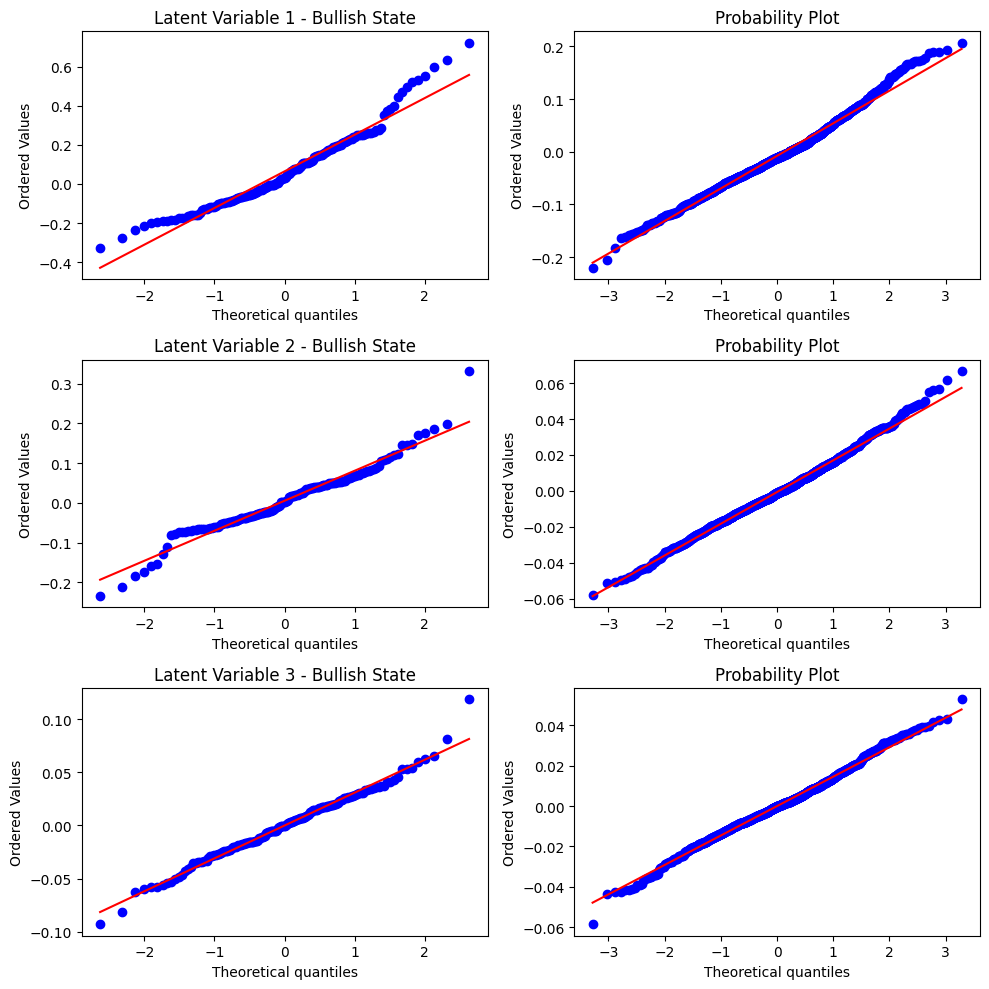

In [76]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,10))
for i in range(X_bear.shape[1]):
    
    stats.probplot(X_bear[:, i], dist='norm', plot=axes[i,0])
    axes[i,0].set_title(f'Latent Variable {i+1} - Bearish State')
    
    stats.probplot(X_bull[:, i], dist='norm', plot=axes[i,1])
    axes[i,0].set_title(f'Latent Variable {i+1} - Bullish State')

plt.tight_layout()
plt.show()

Transition Matrix for the Model

In [10]:
transition_matrix = hmm_model.transmat_
transition_matrix

array([[0.64884697, 0.35115303],
       [0.05228678, 0.94771322]])

State Means => Mean of the distribution of the features under a given state 
    - Positive indicates that the feature contributions 

In [11]:
df_means = pd.DataFrame(
    hmm_model.means_,
    columns = Saved_PC,
)
df_means

,PC1,PC2,PC3
0,0.053182,0.004639,-0.000047
1,-0.008028,-0.000700,0.000007


In [12]:
train_score = np.round(hmm_model.score(latent_train), decimals=3)
print(f'Log-Likelihood of Training Data: {train_score}')

Log-Likelihood of Training Data: 9427.63


In [24]:
train_score/len(train_data)

np.float64(6.247601060304837)

In [13]:
test_score = np.round(hmm_model.score(latent_test), decimals=3)

print(f"Log-Lkelihood of the Test Data: {test_score}")

Log-Lkelihood of the Test Data: 2031.318


Have to normalize to the length of data since the loglikelihood is just a sum of loglikelihood over the entire sequence so naturally longer sequences will have a greater score

In [25]:
test_score/len(test_data)

np.float64(6.6382941176470585)

In [23]:
hmm_model.bic(latent_test)

np.float64(-3976.782653081617)

In [14]:
probs_test = pd.Series(hmm_model.predict(latent_test), index = test_data.index)

probs_train = pd.Series(hmm_model.predict(latent_train), index = train_data.index)

Text(0, 0.5, 'Daily % Returns')

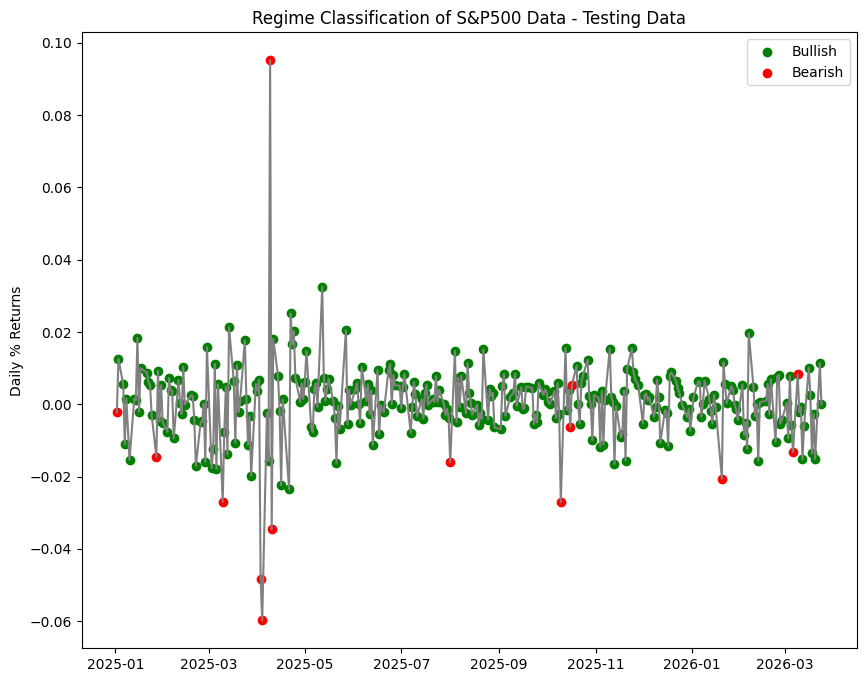

In [20]:
plt.figure(figsize=(10,8))
plt.plot(test_data['^SPX'], color='gray')
plt.scatter(test_data.index[probs_test == 1], test_data['^SPX'][probs_test == 1], color='green', label = 'Bullish')
plt.scatter(test_data.index[probs_test == 0], test_data['^SPX'][probs_test == 0], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data - Testing Data")
plt.legend()
plt.ylabel("Daily % Returns")

Text(0, 0.5, 'Daily % Returns')

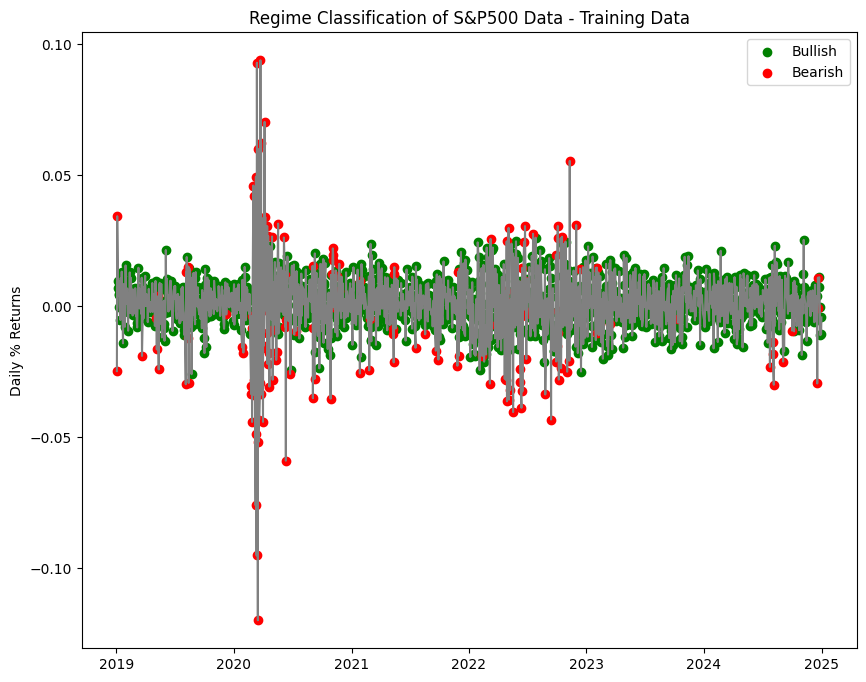

In [19]:
plt.figure(figsize=(10,8))
plt.plot(train_data['^SPX'], color='gray')
plt.scatter(train_data.index[probs_train == 1], train_data['^SPX'][probs_train  == 1], color='green', label = 'Bullish')
plt.scatter(train_data.index[probs_train  == 0], train_data['^SPX'][probs_train  == 0], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data - Training Data")
plt.legend()
plt.ylabel("Daily % Returns")